In [1]:
from utils.logger import get_logger
from src.data_extractor.data_preparer import FlightDataPreparer, ModelType
from src.data_extractor.data_extractor import FlightDataExtractor
from src.models.reservoir_computing_model import IPReservoirComputingModel
from utils.io import read_csv_file
import matplotlib.pyplot as plt
import numpy as np

In [2]:
logger = get_logger("Trainer")

In [3]:
DATA_SUFFIX = "extra_large"
EXTRACT_DATA = True

In [4]:
if EXTRACT_DATA:
    AIR_CSV_LIST = [
        "./data/datasets/opensky/raw/states_2022-01-03-00.csv/states_2022-01-03-00.csv",
        "./data/datasets/opensky/raw/states_2022-01-03-01.csv/states_2022-01-03-01.csv",
    ]

    processor = FlightDataExtractor(
        metadata_file=f"./data/datasets/opensky/metadata/data_schema/dataset_{DATA_SUFFIX}_metadata.json",
        dataset_suffix=DATA_SUFFIX,
        base_path="./data/datasets/opensky/preprocessed",
        trans_path="./data/datasets/opensky/metadata/transformations"
    )
    processor.run_pipeline(AIR_CSV_LIST)

Successfully loaded JSON as a dictionary.
[2026-04-27 19:21:54] - INFO [FlightDataExtractor]: Reading metadata from ./data/datasets/opensky/metadata/data_schema/dataset_extra_large_metadata.json
[2026-04-27 19:21:54] - INFO [FlightDataExtractor]: Processing ./data/datasets/opensky/raw/states_2022-01-03-00.csv/states_2022-01-03-00.csv...
Successfully loaded CSV. Shape: (2103859, 16)
Error: The variable vertrate casting failed: cannot safely cast non-equivalent object to int64
Error: The variable lastposupdate casting failed: cannot safely cast non-equivalent float64 to int64
Error: The variable lastcontact casting failed: cannot safely cast non-equivalent float64 to int64
[2026-04-27 19:21:58] - INFO [FlightDataExtractor]: Processing ./data/datasets/opensky/raw/states_2022-01-03-01.csv/states_2022-01-03-01.csv...
Successfully loaded CSV. Shape: (1951306, 16)
Error: The variable vertrate casting failed: cannot safely cast non-equivalent object to int64
Error: The variable lastposupdate c

In [5]:
train_df = read_csv_file(f"./data/datasets/opensky/preprocessed/train/data_{DATA_SUFFIX}.csv")
val_df = read_csv_file(f"./data/datasets/opensky/preprocessed/val/data_{DATA_SUFFIX}.csv")
test_df = read_csv_file(f"./data/datasets/opensky/preprocessed/test/data_{DATA_SUFFIX}.csv")

display(train_df)
display(val_df)
display(test_df)

Successfully loaded CSV. Shape: (2227144, 16)
Successfully loaded CSV. Shape: (539590, 16)
Successfully loaded CSV. Shape: (489969, 16)


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,1.125218,-0.553913,0.435131,0.438556,-0.352960,2.659376,5.368318,-0.897729,-0.930259,0.632723,-0.774378,1641168010,0,0,0,3c4582.0
1,1.142489,0.198391,0.461729,-0.907274,0.088551,0.014306,0.121706,0.912355,0.826150,-0.966279,0.257497,1641168010,0,0,0,4ca8e8.0
2,0.554535,0.563995,0.443059,0.680354,0.922952,-0.035045,0.056123,1.057598,1.105374,0.790564,0.612380,1641168020,0,0,0,06a30c.0
3,0.015515,0.212421,-0.640967,-0.018416,-1.726665,0.014306,-0.337373,-1.814572,-1.791349,-0.014924,0.999889,1641168020,0,0,0,a81032.0
4,0.084167,-0.009877,-0.688867,-0.019034,0.486855,0.262669,0.056123,0.621870,0.642402,-0.907072,0.420975,1641168020,0,0,0,a0d561.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227139,0.442401,0.461426,-0.624973,0.646332,0.754326,0.244152,0.056123,0.694492,0.664020,0.839570,0.543251,1641175190,0,0,0,a2c1bd.1
2227140,0.308457,-0.009877,-0.832641,-0.019034,0.428855,0.014306,0.121706,0.767113,0.773908,-0.999526,-0.030791,1641175190,0,0,0,a11d47.3
2227141,-0.517281,-0.009877,1.728771,-0.019034,0.471152,0.014306,0.974280,-0.427507,-0.368208,0.252422,0.967617,1641175190,0,0,0,781b94.0
2227142,0.274200,-0.009877,1.784340,-0.019034,-0.115989,0.014306,-0.927617,-0.129760,-0.159240,-0.987530,-0.157432,1641175190,0,0,0,781157.2


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,0.454750,-0.412413,-0.376628,-0.187448,-1.390632,0.244421,-0.009460,-1.625757,-1.649035,-0.424720,-0.905325,1641168020,0,0,0,abea64.0
1,-0.230469,0.612409,-0.624549,-0.379125,0.236096,0.073044,0.056123,0.623686,0.678431,-0.590270,0.807206,1641168020,0,0,0,abb3b6.0
2,0.461195,0.435235,-0.380022,-0.084227,-1.496723,3.713178,1.039863,-1.678407,-1.697674,-0.145669,0.989333,1641168020,0,0,0,ab40ce.0
3,0.082941,-0.879007,-0.673333,0.881666,0.913257,0.186794,0.056123,0.694492,0.712659,0.776240,-0.630438,1641168020,0,0,0,ac205f.0
4,0.071096,-0.590651,-0.626919,-0.466928,0.881020,0.014306,-0.927617,0.164356,0.168623,-0.677505,-0.735518,1641168020,0,0,0,ab2729.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539585,0.686978,-0.194469,-0.649521,1.009214,1.182636,0.061706,0.056123,1.275461,1.199049,0.984745,-0.174003,1641175190,0,0,0,aae34c.0
539586,0.114476,-0.184051,-0.878382,0.399285,-0.645020,0.014306,0.056123,0.113522,0.134395,0.943914,-0.330191,1641175190,0,0,0,a9926b.1
539587,-0.155468,-0.006006,-0.586865,-0.347127,-0.462669,0.014306,0.121706,0.912355,0.968464,-0.999978,0.006601,1641175190,0,0,0,ababaf.1
539588,0.300470,0.379112,-0.508016,-0.618365,0.252691,0.014306,-0.009460,0.765297,0.746886,-0.867934,0.496679,1641175190,0,0,0,ab2504.0


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,-3.127935,-0.315133,-0.072904,-0.171713,-0.905581,0.014306,-0.730869,-1.266282,-1.249115,-0.553753,-0.832681,1641168020,0,0,0,e48003.0
1,-3.127148,0.630988,-0.073944,-0.428996,0.412256,-1.175492,-2.370435,-0.810584,-0.768129,-0.647648,0.761939,1641168020,0,0,0,e49329.0
2,0.217623,0.815193,-0.475728,-0.381478,0.873636,0.014306,0.056123,0.912355,0.927031,-0.454672,0.890659,1641168020,0,0,0,ad7760.0
3,0.249408,-0.482083,-0.823224,-0.474595,0.119701,-0.005107,0.056123,1.273646,1.281915,-0.740415,-0.672150,1641168020,0,0,0,ad5658.0
4,0.190320,-0.197598,-0.839459,-0.427605,-0.744223,-0.086250,-1.649026,-1.175505,-1.171652,-0.930797,-0.365536,1641168020,0,0,0,ac58b9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489964,0.568851,0.004412,-0.395118,1.103347,1.863746,0.014306,0.121706,0.549249,0.494684,0.999935,0.011400,1641175190,0,0,0,acf54f.1
489965,-3.894501,-0.173730,2.421444,-0.333773,-1.198772,1.665036,0.121706,-1.633019,-1.613006,-0.914013,-0.405685,1641175190,0,1,0,c818da.1
489966,-2.292795,-0.736216,0.034660,-0.335029,0.550138,0.014306,0.056123,0.912355,1.056735,-0.529179,-0.848510,1641175190,0,0,0,e07246.0
489967,-4.153812,-0.028294,2.416199,0.208550,-1.843287,0.582410,-0.075042,-1.420602,-1.405840,0.996428,-0.084443,1641175190,0,0,0,c805a0.2


In [6]:
data_preparer = FlightDataPreparer(target_column="velocity", window_size=12, required_length=100)

X_train_rc, y_train_rc, icao_list_train_rc = data_preparer.transform(train_df, model_type=ModelType.RESERVOIR_COMPUTING)
X_val_rc, y_val_rc, icao_list_val_rc = data_preparer.transform(val_df, model_type=ModelType.RESERVOIR_COMPUTING)
X_test_rc, y_test_rc, icao_list_test_rc = data_preparer.transform(test_df, model_type=ModelType.RESERVOIR_COMPUTING)

In [7]:
rc_params_default = {
    "units": 100,
    "sr": 0.9,
    "mu": 0.1,
    "input_scaling": 1,
    "learning_rate": 0.1,
    "rc_connectivity": 0.4,
    "input_connectivity": 0.4,
    "activation": "sigmoid",
    "epochs": 1000,
    "warmup_steps": 15,
    "ridge": 0.5,
    "seed": 33,
}
rc_model = IPReservoirComputingModel(name="rc_test", params=rc_params_default)
logger.info("Start fitting RC model")
rc_model.fit(X_train_rc, y_train_rc)
logger.info("RC model succesfully fitted")
y_pred_rc = rc_model.predict(X_test_rc)
logger.info(rc_model.evaluate(y_test_rc, y_pred_rc))
rc_model.save_model()

[2026-04-26 14:00:18] - INFO [Trainer]: Start fitting RC model
[2026-04-26 14:01:07] - INFO [IPReservoirComputingModel]: Training time: 49.66455888748169
[2026-04-26 14:01:08] - INFO [Trainer]: RC model succesfully fitted
[2026-04-26 14:01:20] - INFO [Trainer]: 0.8377015486459191
Successfully saved JSON to ./data/models\rc_test\1777204818\params.json. Items: 12
Successfully saved NPY to ./data/models\rc_test\1777204818\readout_weights.npy. Shape: (100, 1)
Successfully saved NPY to ./data/models\rc_test\1777204818\readout_bias.npy. Shape: (1,)


In [ ]:
hpt_rc_model = IPReservoirComputingModel.tune(
    X_train=X_train_rc, 
    y_train=y_train_rc, 
    X_test=X_val_rc, 
    y_test=y_val_rc,
    name="hpt_rc",
    n_iterations=20
)

{'units': np.int64(5), 'sr': np.float64(0.22383410687462496), 'mu': 0.41333135408836763, 'input_scaling': np.float64(0.010006705743063069), 'learning_rate': np.float64(6.038082917747018e-05), 'connectivity': 0.16093164877763405, 'activation': 'tanh', 'ridge': np.float64(0.6816496171469042), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
New best score: 2.5041
Best params: {'units': np.int64(5), 'sr': '2.24e-01', 'mu': '4.13e-01', 'input_scaling': '1.00e-02', 'learning_rate': '6.04e-05', 'connectivity': '1.61e-01', 'activation': 'tanh', 'ridge': '6.82e-01', 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5, 'score': '2.50e+00'}
Iteration 1/20: Score = 2.5041
{'units': np.int64(5), 'sr': np.float64(0.22051378048456205), 'mu': np.float64(0.5138704827687315), 'input_scaling': np.float64(0.00991032384816578), 'learning_rate': np.float64(6.298469893741583e-05), 'connectivity': np.float64(0.14965857060758417), 'activation': 'tanh', 'ridge': np.float64(0.6395222790559

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python

Iteration 6/20: Score = 3.4114
{'units': np.int64(5), 'sr': np.float64(0.207092915822561), 'mu': np.float64(0.39259959984952364), 'input_scaling': np.float64(0.00892352745675319), 'learning_rate': np.float64(6.237569565485539e-05), 'connectivity': np.float64(0.16096136282015722), 'activation': 'tanh', 'ridge': np.float64(0.7855425072025505), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 7/20: Score = 2.4854
{'units': np.int64(5), 'sr': np.float64(0.1498294992074046), 'mu': 0.04914874123395885, 'input_scaling': np.float64(0.33496507720968915), 'learning_rate': np.float64(3.669235020141026e-05), 'connectivity': 0.29868429200954805, 'activation': 'sigmoid', 'ridge': np.float64(7.095716836293026e-05), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 8/20: Score = 3.0346
{'units': np.int64(5), 'sr': np.float64(1.5772164760494076), 'mu': 0.20211511155964812, 'input_scaling': np.float64(0.00743858604429673), 'learning_rate': np.float64(0.000107

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))


Iteration 10/20: Score = 2.7907
{'units': np.int64(100), 'sr': np.float64(5.056953417274923), 'mu': 0.3914149625523332, 'input_scaling': np.float64(124.54402308334197), 'learning_rate': np.float64(0.00019369057893303928), 'connectivity': 0.11853962332690227, 'activation': 'tanh', 'ridge': np.float64(0.014954047495749417), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 11/20: Score = 1.9535
{'units': np.int64(5), 'sr': np.float64(2.4686958300087687), 'mu': 0.5944105818500308, 'input_scaling': np.float64(0.014876634248081914), 'learning_rate': np.float64(0.0003392994704607839), 'connectivity': 0.19507594435447737, 'activation': 'sigmoid', 'ridge': np.float64(0.07412381027404685), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}


c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))


Iteration 12/20: Score = 2.8868
{'units': np.int64(5), 'sr': np.float64(0.216442246402899), 'mu': np.float64(0.4499754746092145), 'input_scaling': np.float64(0.010216794769316856), 'learning_rate': np.float64(6.715217418314344e-05), 'connectivity': np.float64(0.11894345765154901), 'activation': 'tanh', 'ridge': np.float64(0.5416279330648369), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 13/20: Score = 2.6752
{'units': np.int64(50), 'sr': np.float64(0.2252333045084789), 'mu': np.float64(0.4373312311451614), 'input_scaling': np.float64(0.010393871591805413), 'learning_rate': np.float64(5.190666279679095e-05), 'connectivity': np.float64(0.1753826424528577), 'activation': 'tanh', 'ridge': np.float64(0.688192239513008), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
New best score: 0.6862
Best params: {'units': np.int64(50), 'sr': '2.25e-01', 'mu': '4.37e-01', 'input_scaling': '1.04e-02', 'learning_rate': '5.19e-05', 'connectivity': '1.75e-01', 'act

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: overflow encountered in exp
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\reservoirpy\activationsfunc.py:131: RuntimeWarning: invalid value encountered in divide
  return np.where(x < 0, np.exp(x) / (np.exp(x) + 1.0), 1.0 / (1.0 + np.exp(-x)))
c:\Users\camar\AppData\Local\Programs\Python

Iteration 16/20: Score = 1.9277
{'units': np.int64(100), 'sr': np.float64(0.24757520511568737), 'mu': np.float64(0.4678334784352758), 'input_scaling': np.float64(0.00950701013546814), 'learning_rate': np.float64(4.629178603298605e-05), 'connectivity': np.float64(0.19392660384930982), 'activation': 'sigmoid', 'ridge': np.float64(0.6612743118637168), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
Iteration 17/20: Score = 0.7075
{'units': np.int64(100), 'sr': np.float64(0.23763138091516603), 'mu': np.float64(0.4715461983413208), 'input_scaling': np.float64(0.013781736798856041), 'learning_rate': np.float64(5.6888744926051096e-05), 'connectivity': np.float64(0.1829187609799811), 'activation': 'tanh', 'ridge': np.float64(0.6894146569117366), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5}
New best score: 0.6716
Best params: {'units': np.int64(100), 'sr': '2.38e-01', 'mu': '4.72e-01', 'input_scaling': '1.38e-02', 'learning_rate': '5.69e-05', 'connectivity': '1.83

c:\Users\camar\OneDrive\Escritorio\Master\TFM\reservoir-computing-flight-prediction\src\hpt\hp_visualizer.py:75: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(df[column], df['score'])


In [9]:
y_pred_hpt_rc = hpt_rc_model.predict(X_test_rc)
hpt_rc_model.evaluate(y_test_rc, y_pred_hpt_rc)

0.6720007404220494

In [10]:
hpt_rc_model.params

{'units': np.int64(100),
 'sr': np.float64(0.23763138091516603),
 'mu': np.float64(0.4715461983413208),
 'input_scaling': np.float64(0.013781736798856041),
 'learning_rate': np.float64(5.6888744926051096e-05),
 'connectivity': np.float64(0.1829187609799811),
 'activation': 'tanh',
 'ridge': np.float64(0.6894146569117366),
 'epochs': 100,
 'warmup': 15,
 'seed': 12345,
 'n_instances': 5,
 'score': np.float64(0.6715739128593086)}

In [11]:
hpt_rc_model.save_model()

[2026-04-25 23:35:50] - INFO [IPReservoirComputingModelRC]: The model params are {'units': np.int64(100), 'sr': np.float64(0.23763138091516603), 'mu': np.float64(0.4715461983413208), 'input_scaling': np.float64(0.013781736798856041), 'learning_rate': np.float64(5.6888744926051096e-05), 'connectivity': np.float64(0.1829187609799811), 'activation': 'tanh', 'ridge': np.float64(0.6894146569117366), 'epochs': 100, 'warmup': 15, 'seed': 12345, 'n_instances': 5, 'score': np.float64(0.6715739128593086)}
Successfully saved JSON to ./data/models\hpt_rc\1777152880\params.json. Items: 13
Successfully saved NPY to ./data/models\hpt_rc\1777152880\readout_weights.npy. Shape: (100, 1)


## LSTM

In [6]:
import torch
from src.models.lstm_model import LSTMRegressorModel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [ ]:
data_preparer = FlightDataPreparer(target_column="velocity", window_size=12, required_length=100)

train_dataloader_lstm, n_features_train, icao_list_train_rc = data_preparer.transform(train_df, model_type=ModelType.LSTM)
val_dataloader_lstm, n_features_train, icao_list_train_rc = data_preparer.transform(val_df, model_type=ModelType.LSTM)
test_dataloader_lstm, n_features_test, icao_list_test_rc = data_preparer.transform(test_df, model_type=ModelType.LSTM)

In [ ]:
model_params_lstm = {
    "input_size": n_features_train,
    "hidden_size": 32,
    "num_layers": 2,
    "lr": 1e-4,
    "epochs": 100,
    "patience": 5,
    "device": device
}

model_lstm = LSTMRegressorModel(name="lstm_test", params=model_params_lstm)

model_lstm.fit(train_dataloader_lstm, val_dataloader_lstm)
y_true_lstm, y_pred_lstm = model_lstm.predict(test_dataloader_lstm)
logger.info(model_lstm.evaluate(y_true_lstm, y_pred_lstm))
model_lstm.save_model()

[2026-04-26 12:48:04] - INFO [LSTMRegressorModel]: Epoch 0 | Train Loss: 0.757387 | Val Loss: 0.570796
[2026-04-26 12:50:06] - INFO [LSTMRegressorModel]: Epoch 1 | Train Loss: 0.639677 | Val Loss: 0.573918
[2026-04-26 12:52:07] - INFO [LSTMRegressorModel]: Epoch 2 | Train Loss: 0.618551 | Val Loss: 0.573275
[2026-04-26 12:54:11] - INFO [LSTMRegressorModel]: Epoch 3 | Train Loss: 0.607253 | Val Loss: 0.574935
[2026-04-26 12:56:22] - INFO [LSTMRegressorModel]: Epoch 4 | Train Loss: 0.598872 | Val Loss: 0.563084
[2026-04-26 12:58:28] - INFO [LSTMRegressorModel]: Epoch 5 | Train Loss: 0.590609 | Val Loss: 0.561466
[2026-04-26 13:00:30] - INFO [LSTMRegressorModel]: Epoch 6 | Train Loss: 0.580222 | Val Loss: 0.545932
[2026-04-26 13:02:31] - INFO [LSTMRegressorModel]: Epoch 7 | Train Loss: 0.565703 | Val Loss: 0.538800
[2026-04-26 13:04:36] - INFO [LSTMRegressorModel]: Epoch 8 | Train Loss: 0.557084 | Val Loss: 0.532660
[2026-04-26 13:06:40] - INFO [LSTMRegressorModel]: Epoch 9 | Train Loss: 

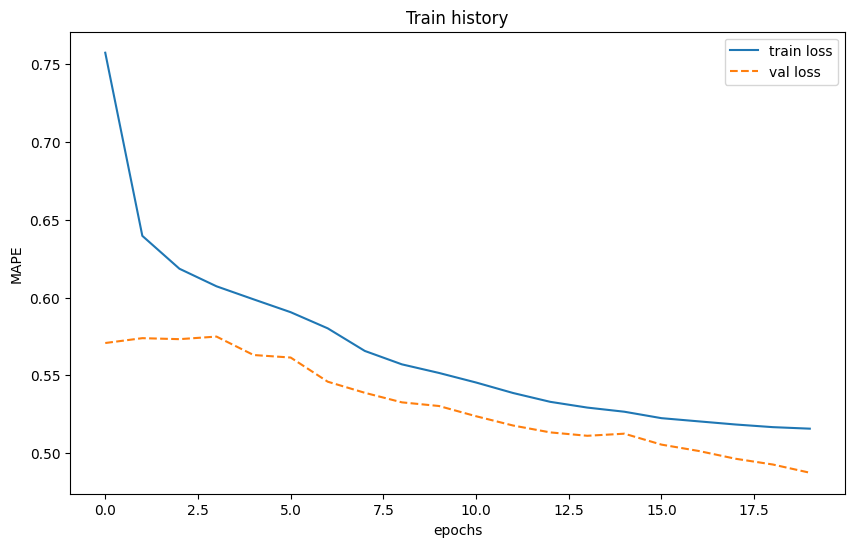

Plot rendered successfully.


In [9]:
model_lstm.plot_history()